# Chapter 35: Memory Optimization for Large Datasets

**At what ID size does a blanket float32 downcast start merging customers, and how much memory does it save compared with a checked downcast?**

Memory work that silently changes the data is worse than a crash: the run finishes, the score drops, and nothing points at the dtype. The chapter's check compares values and distinct counts before accepting a smaller type.

*Constructed data on this machine's pandas; the savings are properties of this table, not a general rule.*

## The experiment

A constructed table of 200,000 purchases from 40,000 customers: an integer customer ID that starts at the control value, an amount in dollars and cents, and a long region string. Three versions are compared: unchanged, a blanket float32 for the ID and amount columns, and a checked downcast (float32 only when the chapter's value and distinct-count check passes, int32 only when the range fits, repeated strings as categories). Each is scored by its memory, by how many distinct IDs remain, and by R-squared of a held-out-rows prediction from the mean amount per customer ID.

In [1]:
import tracemalloc

import numpy as np
import pandas as pd

from kaggle_companion.activities._common import clean

SEED = 35
ROWS, CUSTOMERS = 200_000, 40_000
REGIONS = [f"region_{i:02d}_north_america_east" for i in range(12)]   # a long, repeated string column
INT32_MAX = np.iinfo(np.int32).max


def generate(first_id, rng):
    """Purchases: a customer ID that starts at `first_id`, an amount whose mean depends on the customer, and a region string."""
    customer = rng.integers(0, CUSTOMERS, ROWS)
    taste = rng.normal(0, 1, CUSTOMERS)
    amount = np.round(60 * np.exp(0.6 * taste[customer] + rng.normal(0, 0.3, ROWS)), 2)
    return pd.DataFrame({"customer_id": (first_id + customer).astype(np.int64), "amount": amount,
                         "region": np.array(REGIONS)[rng.integers(0, 12, ROWS)]})


def blanket_float32(df):
    """The shortcut: every numeric column becomes float32 because the range fits."""
    out = df.copy()
    for name in ("customer_id", "amount"):
        out[name] = df[name].astype(np.float32)
    return out


def checked_downcast(df):
    """The chapter's information check: float32 only if values and distinct counts survive; integers shrink only if the range fits."""
    out = df.copy()
    for name in ("customer_id", "amount"):
        values = df[name].to_numpy()
        if values.dtype.kind == "i":
            if values.min() >= np.iinfo(np.int32).min and values.max() <= INT32_MAX:
                out[name] = values.astype(np.int32)
        else:
            candidate = values.astype(np.float32)
            same_values = np.allclose(values, candidate.astype(np.float64), atol=1e-7, rtol=1e-5)
            if same_values and np.unique(values).size == np.unique(candidate).size:
                out[name] = candidate
    out["region"] = df["region"].astype("category")        # repeated strings stored once
    return out


def customer_feature(df, train, fallback):
    """The feature a competitor would build: mean amount per customer ID on training rows, mapped onto held-out rows."""
    per_id = df[train].groupby("customer_id")["amount"].mean()
    return df.loc[~train, "customer_id"].map(per_id).fillna(fallback).to_numpy(dtype=float)


def run(first_id_power):
    rng = np.random.default_rng(SEED)
    df = generate(2 ** first_id_power, rng)
    train = np.arange(ROWS) % 2 == 0                        # even rows build the feature, odd rows are scored against it
    truth = df.loc[~train, "amount"].to_numpy()
    original_mb = df.memory_usage(deep=True).sum() / 1e6
    schemes = {}
    for name, convert in (("none", lambda d: d.copy()), ("blanket", blanket_float32), ("checked", checked_downcast)):
        tracemalloc.start()                                 # measure what the conversion itself allocates at its peak
        frame = convert(df)
        conversion_peak_mb = tracemalloc.get_traced_memory()[1] / 1e6
        tracemalloc.stop()
        feature = customer_feature(frame, train, df.loc[train, "amount"].mean())
        columns = frame.memory_usage(deep=True)
        schemes[name] = {
            "megabytes": columns.sum() / 1e6,
            "by_column": {"Customer ID": columns["customer_id"] / 1e6, "Amount": columns["amount"] / 1e6,
                          "Region": columns["region"] / 1e6},
            # measured peak while converting: the original table stays alive while the conversion allocates
            "conversion_peak": round(0.0 if name == "none" else conversion_peak_mb, 1),
            "while_converting": round(original_mb + (0.0 if name == "none" else conversion_peak_mb), 1),
            "distinct_ids": int(frame["customer_id"].nunique()),
            "feature_r2": float(np.corrcoef(feature, truth)[0, 1] ** 2),
            "max_amount_error_cents": float(100 * np.abs(frame["amount"].astype(np.float64) - df["amount"]).max()),
            "id_dtype": str(frame["customer_id"].dtype),
        }
    return clean({"first_id_power": first_id_power, "first_id": 2 ** first_id_power, "true_ids": int(df["customer_id"].nunique()),
                  "schemes": schemes, "rows": ROWS})


## Measure it across the control

The control is **smallest customer id, as a power of two**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch35 import explain

VALUES = [22, 24, 26, 33]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                          22                24               26            33
Unchanged table                      18.6 MB           18.6 MB          18.6 MB       18.6 MB
Blanket float32                      17.0 MB           17.0 MB          17.0 MB       17.0 MB
Checked downcast                      1.8 MB            1.8 MB           1.8 MB        2.6 MB
Distinct IDs after blanket  39,756 of 39,756  19,933 of 39,756  5,001 of 39,756  40 of 39,756
R-squared, blanket                     0.600             0.271            0.060         0.001
R-squared, checked                     0.600             0.600            0.600         0.600


## Look at it

The figure shows the default setting, smallest customer id, as a power of two = 24.

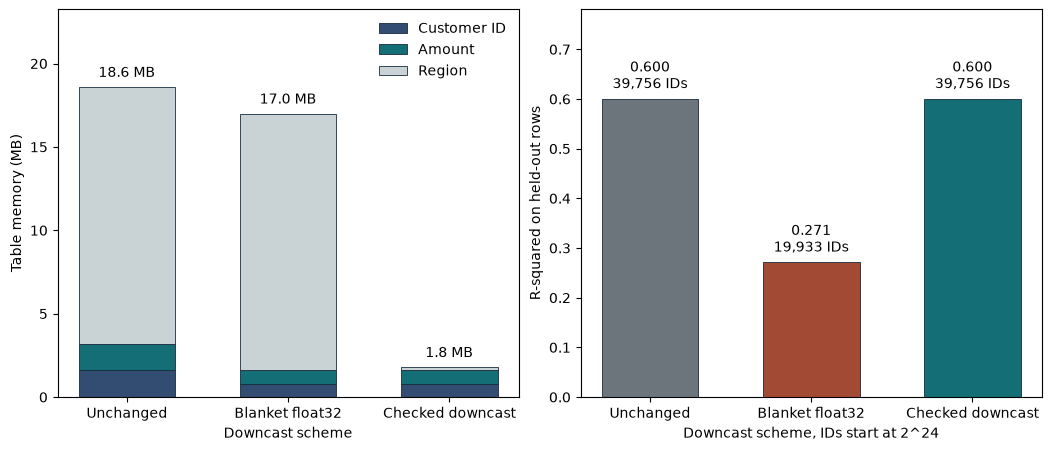

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch35 import draw, NCOLS, HEIGHT

DEFAULT = 24
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With IDs starting at 2^24: the table is 18.6 MB unchanged, 17.0 MB with blanket float32 (18.6 - 17.0 = 1.6 MB saved) and 1.8 MB checked (18.6 - 1.8 = 16.8 MB saved, ID stored as int32). 19,823 of 39,756 IDs vanish into a neighbor, and the held-out R-squared falls from 0.600 to 0.271. The checked table keeps all 39,756 IDs and R-squared 0.600. Amounts change by at most 0.003 cents.

- Memory saved by the blanket downcast: 18.6 - 17.0 = 1.6 MB.
- Memory saved by the checked downcast: 18.6 - 1.8 = 16.8 MB.
- Customers merged by float32: 39756 - 19933 = 19823.
- R-squared lost to the blanket downcast: 0.600 - 0.271 = 0.329.
- Measured peak while converting to the checked table: 18.6 + 11.4 = 30.0 MB (the original table plus the conversion's own peak allocation).

## Apply this to your competition

- Compare distinct counts and task-unit error before and after every downcast; never accept a type because the range fits.
- Keep IDs, timestamps and money differences in an integer or float64 type unless the check passes.
- Find where the bytes are first (here, strings) and measure the table: the numeric downcast is often the smaller saving.
- Remember the conversion copy: the original and the new column coexist, so convert in chunks when memory is already tight.

Book location: Chapter 35, Downcast With an Information Check.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)